In [ ]:
#This notebook generates the ann-based figures that comprise Figure 3 in the paper

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyrenn
sns.set(style='ticks')
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from pickle import load
import matplotlib.gridspec as gridspec
import ast
import sys
BMS_path='../bin/'
sys.path.append(BMS_path + 'no_degeneracy/')
sys.path.append(BMS_path + 'no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par

resolutions=['1x', '2x', '4e-3x']

#colors from seaborn's colorblind palette
#-----------------------------------------------
color_data=sns.color_palette("colorblind")[0]
color_noise=sns.color_palette("colorblind")[7]
color_ann=sns.color_palette("colorblind")[4]
color_bms=sns.color_palette("colorblind")[2]

colors={'4e-3x':['#fee0d2', '#deebf7'],
       '2x':['#fc9272', '#9ecae1'],
       '1x':['#de2d26', '#3182bd'] }
#-----------------------------------------------

In [12]:
#A function to return mdl models from traces
#------------------------------------------------------
def get_mdl(df_var, trace_var,dimensions=False ):
    
    #Two-dimensional (only nguyen n=10) or one-dimensional functions
    if dimensions==True:
         VARS = ['x','y',]
         prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
    else:
        VARS = ['x',]
        prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')

    #Discriminate ann-generated vs nugyen functions
    try:
        x = df_var[[c for c in VARS]].copy()
        y=df_var.z_noise
    except KeyError:
        VARS = ['x1',]
        x = df_var[[c for c in VARS]].copy()
        y=df_var.y_noise
        
    
    minrow = trace_var[trace_var.H == min(trace_var.H)].iloc[0]
    minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)
    
    tvar= Tree(
        variables=list(x.columns),
        parameters=['a%d' % i for i in range(NPAR)],
        x=x, y=y,
        prior_par=prior_par,
        max_size=200,
        from_string=minexpr,
    )

    tvar.set_par_values(deepcopy(minparvals))
    x_var=x;y_var=y
    
    return tvar, x_var, y_var
#------------------------------------------------------

#Errors approximation
#------------------------------------------------------
def get_approximation_errors(resolution):
    #read errors
    errors_approximation=pd.read_csv('../data/'+ 'errors_approximation_' + resolution +  '.csv',index_col=0)
    columns=["sigma", "function","rmse_nn_train", "rmse_nn_test", "rmse_mdl_train", "rmse_mdl_test", "n", "r"]
    errors_approximation=errors_approximation[columns]

    #divide between train/test
    errors_approximation_train=errors_approximation[["sigma","function", "rmse_nn_train", "rmse_mdl_train","n", "r"]]
    errors_approximation_train=pd.melt(errors_approximation_train,id_vars=["sigma","function", "n", "r"], 
                                       var_name="error_train",value_name= "value_train")   

    errors_approximation_test=errors_approximation[["sigma","function", "rmse_nn_test", "rmse_mdl_test","n", "r"]]
    errors_approximation_test=pd.melt(errors_approximation_test,id_vars= ["sigma","function", "n", "r"], var_name="error_test", 
                                      value_name= "value_test")

    #Separate tanh and leaky ReLU
    errors_tanh_train=errors_approximation_train[errors_approximation_train['function']=='tanh']
    errors_tanh_test=errors_approximation_test[errors_approximation_test['function']=='tanh']

    errors_leaky_train=errors_approximation_train[errors_approximation_train['function']=='leaky_ReLU']
    errors_leaky_test=errors_approximation_test[errors_approximation_test['function']=='leaky_ReLU']

    return errors_tanh_train, errors_tanh_test, errors_leaky_train, errors_leaky_test
#------------------------------------------------------

#Errors of interpolation
#------------------------------------------------------
def get_interpolation_errors(resolution):
    #read errors
    errors_inter_extrapolation=pd.read_csv('../data/'+ 'errors_interpolation_' + resolution +  '.csv',index_col=0)
    columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.", "n", "r"]
    errors_inter_extrapolation=errors_inter_extrapolation[columns]

    #divide between train/test
    errors_interpolation=errors_inter_extrapolation[["sigma","function", "rmse_nn_interp.", "rmse_mdl_interp.","n", "r"]]
    errors_interpolation=pd.melt(errors_interpolation,id_vars=["sigma","function", "n", "r"], var_name="error_interp.",
                                 value_name= "value_interp.")   

    errors_extrapolation=errors_inter_extrapolation[["sigma","function", "rmse_nn_extrap.", "rmse_mdl_extrap.","n", "r"]]
    errors_extrapolation=pd.melt(errors_extrapolation,id_vars= ["sigma","function", "n", "r"], var_name="error_extrap.", 
                                 value_name= "value_extrap.")

    #Separate tanh and leaky ReLU
    errors_t_tr=errors_interpolation[errors_interpolation['function']=='tanh']
    errors_t_tt=errors_extrapolation[errors_extrapolation['function']=='tanh']

    errors_l_tr=errors_interpolation[errors_interpolation['function']=='leaky_ReLU']
    errors_l_tt=errors_extrapolation[errors_extrapolation['function']=='leaky_ReLU']

    return errors_t_tr, errors_t_tt, errors_l_tr, errors_l_tt
#------------------------------------------------------


#Figure settings
#--------------------------------

#Paths, extensions, and figure size
#--------------------------------
output_path='../results/paper_figures/figure3_ann/'      
extensions=['.svg', '.png']    
#Define figure size in cm
cm = 1/2.54 #convert inch to cm
width = 16*cm; height=16*cm 
#--------------------------------

#Text and figure sizes  
#--------------------------------
size_axis=16;size_ticks=14;
size_title=16;size_legend=10
line_w=3;marker_data=6;marker_s=8
#--------------------------------

#Individual figures
#--------------------------------
xmin_1=-2.05 ;xmax_1=2.05
ymin_1=-0.15 ;ymax_1=1.1

xtick_labels_1=[-2, -1, 0, 1, 2 ];ytick_labels_1=[ 0, 0.5, 1.0]
#--------------------------------

#General figures
#--------------------------------
#Fonts and sizes
markers = {'rmse_nn': 'o', 'rmse_mdl': 's'}; m_size=6
xtick_labels=np.arange(0.0,0.22,0.04)

resamples=100000; bs_seed=1111
ymin=1e-4;ymax=1.15
#--------------------------------


,x1,y,rep,noise,y_noise,ymodel
0,-1.95,0.029264,8.0,-0.002288,0.026976,0.032321
1,-1.90,0.031695,8.0,0.029933,0.061628,0.033107
2,-1.85,0.034179,8.0,0.034231,0.068410,0.033960
3,-1.80,0.036709,8.0,-0.007464,0.029246,0.034886
4,-1.75,0.039279,8.0,-0.012095,0.027184,0.035892
...,...,...,...,...,...,...
75,1.80,0.983012,8.0,0.058247,1.041259,0.898485
76,1.85,0.986217,8.0,-0.016672,0.969544,0.902247
77,1.90,0.989010,8.0,-0.008702,0.980308,0.905755
78,1.95,0.991424,8.0,-0.022289,0.969135,0.909030


<lambdifygenerated-149>:2: RuntimeWarning: invalid value encountered in power
  return x1 + x1**x1
<lambdifygenerated-150>:2: RuntimeWarning: invalid value encountered in power
  return x1 + x1**x1
<lambdifygenerated-159>:2: RuntimeWarning: invalid value encountered in power
  return _a3_**exp(_a5_*x1) + x1


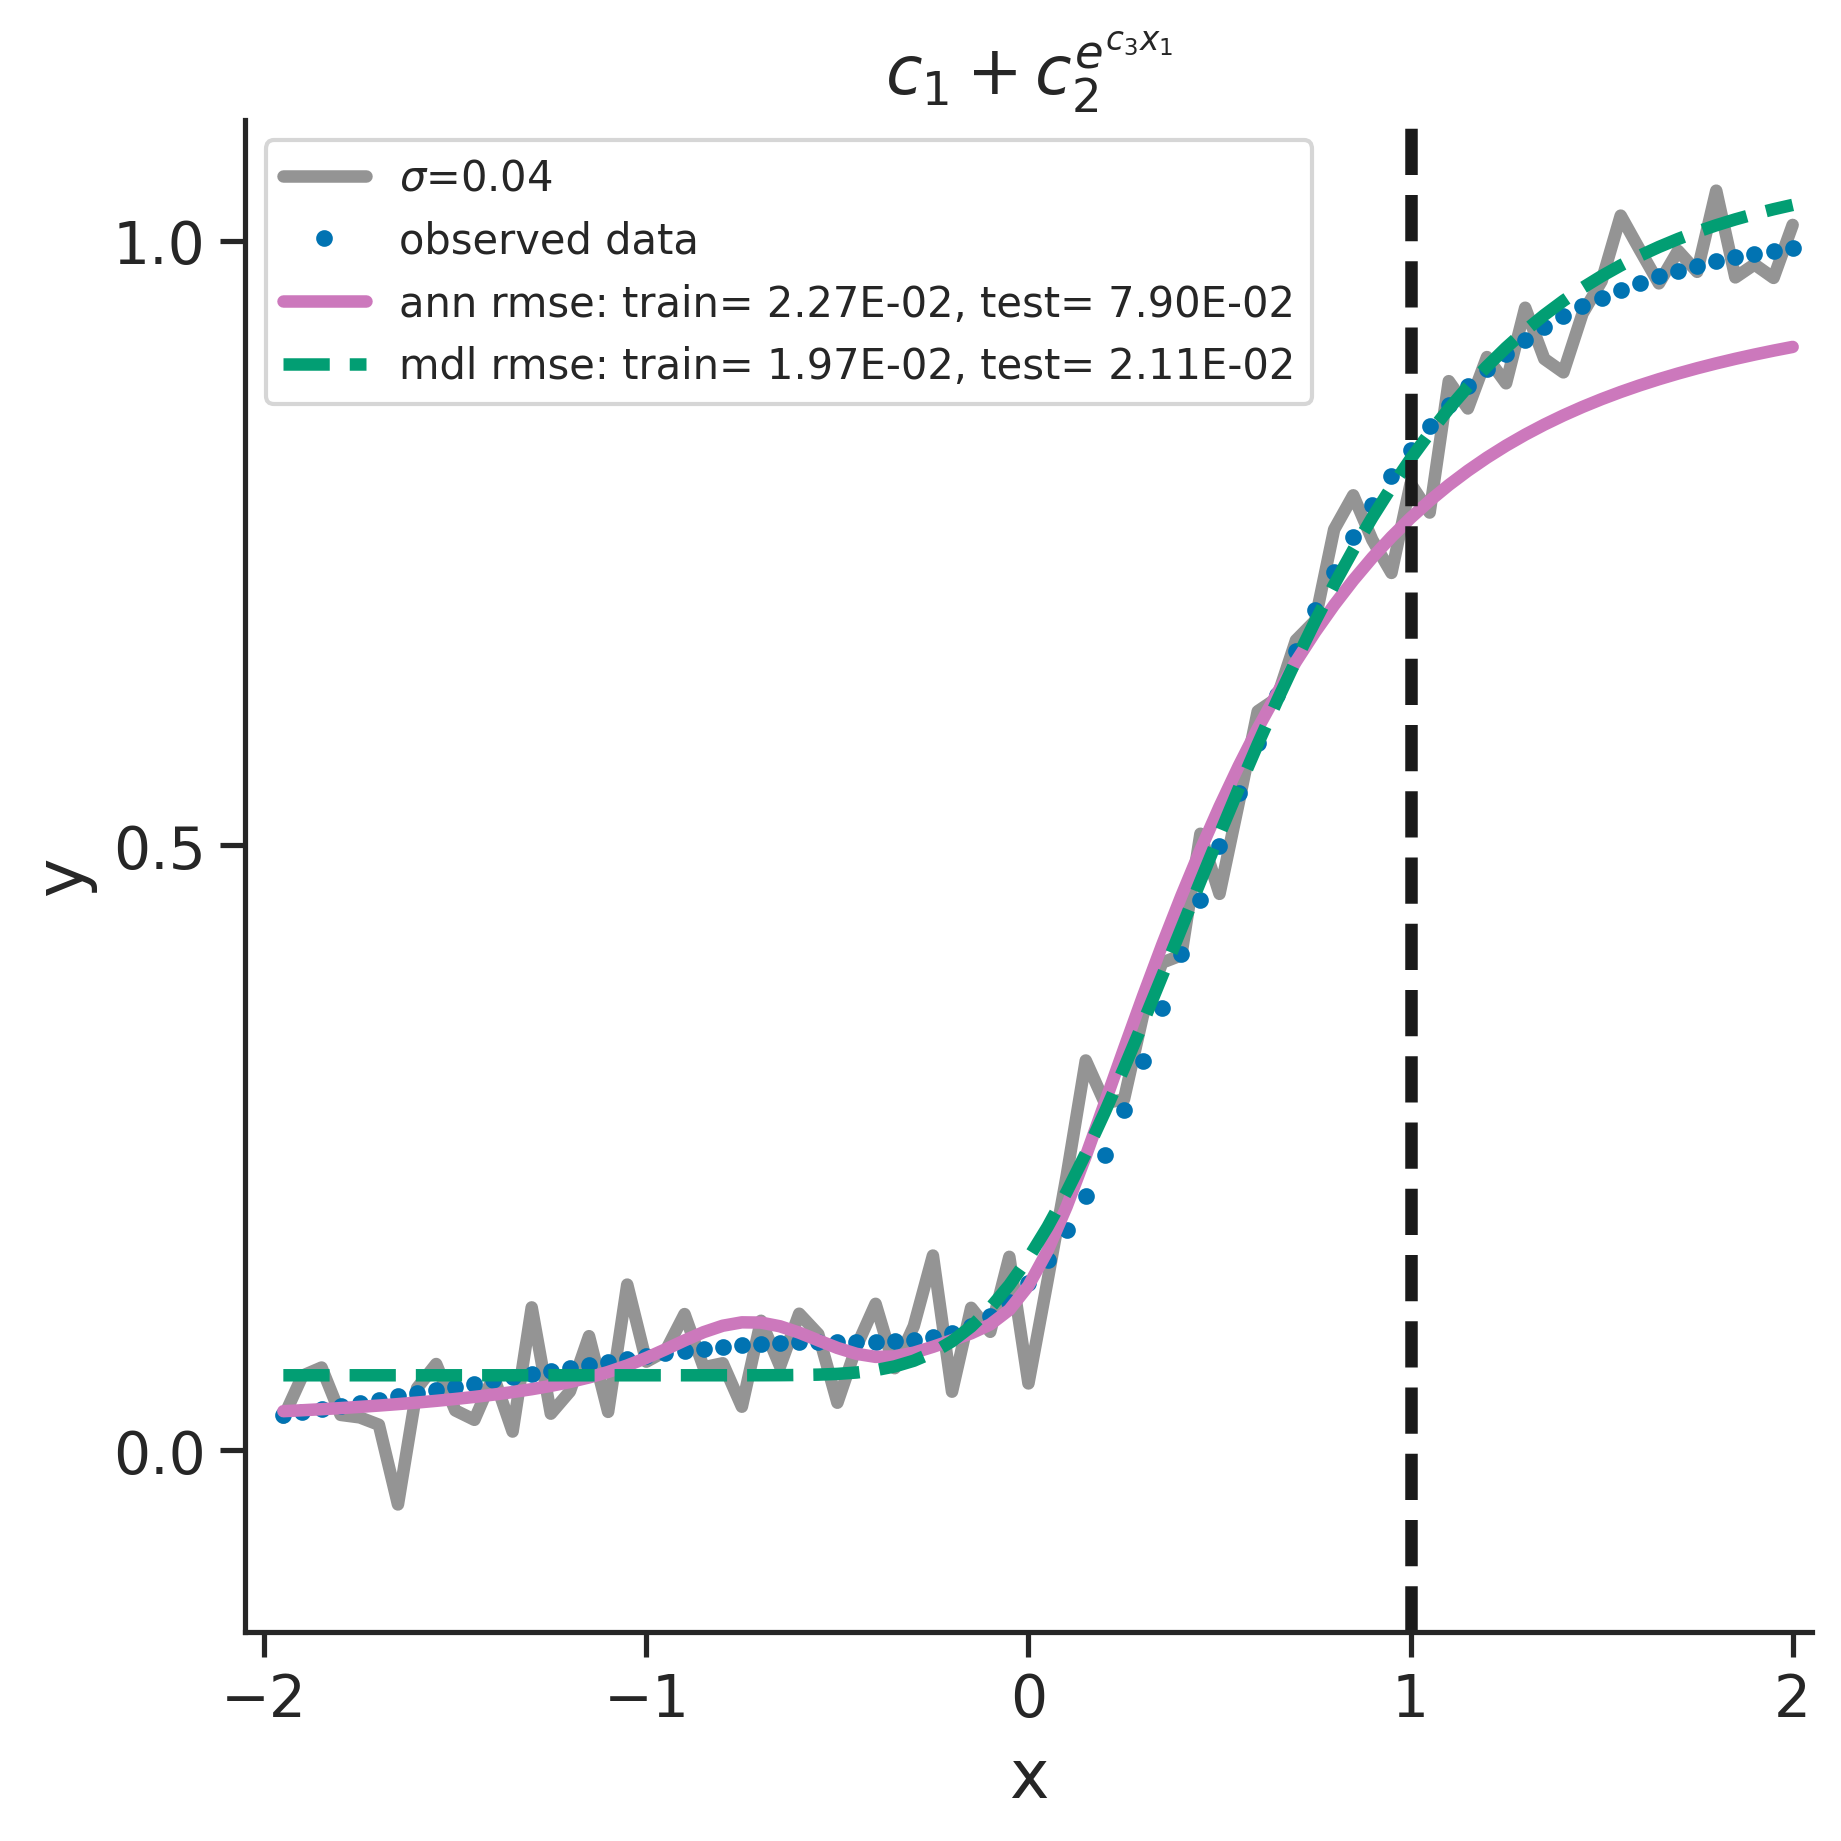

In [14]:
#Plot single tanh figure
NPAR=10;steps=50000

function='tanh';       n=8; sigma=0.04; realization=2
#function='leaky_ReLU'; n=7; sigma=0.08; realization=2


resolution='1x' #'0.5x', '1x', '2x', '4e-3'
resolutions={'1x':'0.05' , '2x': '0.025' , '4e-3x':'0.004' }

#Read NN data
nn_path='../data/nns/' + resolution + '_resolution/approximation/'
file_model='NN_no_overfit_' + function + '_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'

model_d= nn_path + file_model
d=pd.read_csv(model_d,index_col=0)

dn=d[d['rep']==n]
dn=dn.reset_index(drop=True)
display(dn)

#Read BMS trace
bms_path='../data/MSTraces/' + resolution + '_resolution/'
filename='BMS_'+function+'_n_'+str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_res_' + resolutions[resolution] + '_trace_'+\
                str(steps)+'_prior_'+str(NPAR)+ '.csv'

trace=pd.read_csv(bms_path + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
#-------------------------
t,x,y=get_mdl(dn, trace)
#-------------------------

#Validation and train borders
n_points=int(len(dn.index))
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)

train_border=dn.loc[train_size_bms-1]['x1']

dplot = deepcopy(dn)
dplot['ybms'] = t.predict(x)
#display(dplot.loc[train_size_ann-1:])

#compute errors
#ann errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ymodel'],dplot.loc[:train_size_bms -1]['y'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['ymodel'],dplot.loc[train_size_bms -1:]['y'])

#bms errors
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dn.loc[:train_size_bms-1]['y'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dn.loc[train_size_bms-1:]['y'])


fig=figure(figsize=(width,height), dpi=300) 

plt.plot(dn['x1'], dn['y_noise'],linewidth=line_w, color=color_noise,label=r'$\sigma$=' + str(sigma) )
plt.plot(dn['x1'], dn['y'],'.'  ,markersize=marker_data, color=color_data,label='observed data')     
plt.plot(dn['x1'], dn['ymodel'] ,linewidth=line_w, color=color_ann,  label='ann rmse: train= %.2E, test= %.2E' % ( rmse_nn_train, rmse_nn_test))
plt.plot(dplot.x1, dplot.ybms   ,linewidth=line_w, color=color_bms, linestyle='--',label='mdl rmse: train= %.2E, test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))

plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

plt.title('$%s$' %  t.latex(), fontsize=size_title)
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(xtick_labels_1, fontsize=size_ticks);plt.yticks(ytick_labels_1, fontsize=size_ticks)
sns.despine();plt.tight_layout()
plt.legend(loc='best', fontsize=10)

plt.xlim(xmin_1,xmax_1);plt.ylim(ymin_1,ymax_1)

name_fig='%s_%d_%.2f_%d' % (function, n, sigma, realization)
plt.savefig(output_path+name_fig + '.svg',dpi=300)
#plt.savefig(output_path+name_fig + '.png',dpi=300)
#-------------------------------- 


In [47]:
# Initialize combined DataFrames for approximation
combined_tanh_train  = pd.DataFrame()
combined_tanh_test   = pd.DataFrame()
combined_leaky_train = pd.DataFrame()
combined_leaky_test  = pd.DataFrame()

# Initialize combined DataFrames for interpolation
combined_tanh_inter = pd.DataFrame()
combined_tanh_extra = pd.DataFrame()
combined_leaky_inter = pd.DataFrame()
combined_leaky_extra = pd.DataFrame()

# Load and combine data for each resolution
for resolution in resolutions:
    errors_tanh_train, errors_tanh_test, errors_leaky_train, errors_leaky_test = get_approximation_errors(resolution)
    errors_tanh_inter, errors_tanh_extra, errors_leaky_inter, errors_leaky_extra = get_interpolation_errors(resolution)
    
    # Add resolution identifier
    errors_tanh_train['resolution']  = resolution
    errors_tanh_test['resolution']   = resolution
    errors_leaky_train['resolution'] = resolution
    errors_leaky_test['resolution']  = resolution

    errors_tanh_inter['resolution']  = resolution
    errors_tanh_extra['resolution']  = resolution
    errors_leaky_inter['resolution'] = resolution
    errors_leaky_extra['resolution'] = resolution
    
    # Combine DataFrames
    combined_tanh_train  = pd.concat([combined_tanh_train, errors_tanh_train])
    combined_tanh_test   = pd.concat([combined_tanh_test, errors_tanh_test])
    combined_leaky_train = pd.concat([combined_leaky_train, errors_leaky_train])
    combined_leaky_test  = pd.concat([combined_leaky_test, errors_leaky_test])

    combined_tanh_inter = pd.concat([combined_tanh_inter, errors_tanh_inter])
    combined_tanh_extra = pd.concat([combined_tanh_extra, errors_tanh_extra])
    combined_leaky_inter = pd.concat([combined_leaky_inter, errors_leaky_inter])
    combined_leaky_extra = pd.concat([combined_leaky_extra, errors_leaky_extra])

display(combined_tanh_train)


,sigma,function,n,r,error_train,value_train,resolution
330,0.0,tanh,0,0,rmse_nn_train,0.012567,1x
331,0.0,tanh,1,0,rmse_nn_train,0.012049,1x
332,0.0,tanh,2,0,rmse_nn_train,0.007093,1x
333,0.0,tanh,3,0,rmse_nn_train,0.001443,1x
334,0.0,tanh,4,0,rmse_nn_train,0.002433,1x
...,...,...,...,...,...,...,...
1315,0.2,tanh,5,2,rmse_mdl_train,0.037562,4e-3x
1316,0.2,tanh,6,2,rmse_mdl_train,0.034651,4e-3x
1317,0.2,tanh,7,2,rmse_mdl_train,0.019436,4e-3x
1318,0.2,tanh,8,2,rmse_mdl_train,0.022791,4e-3x


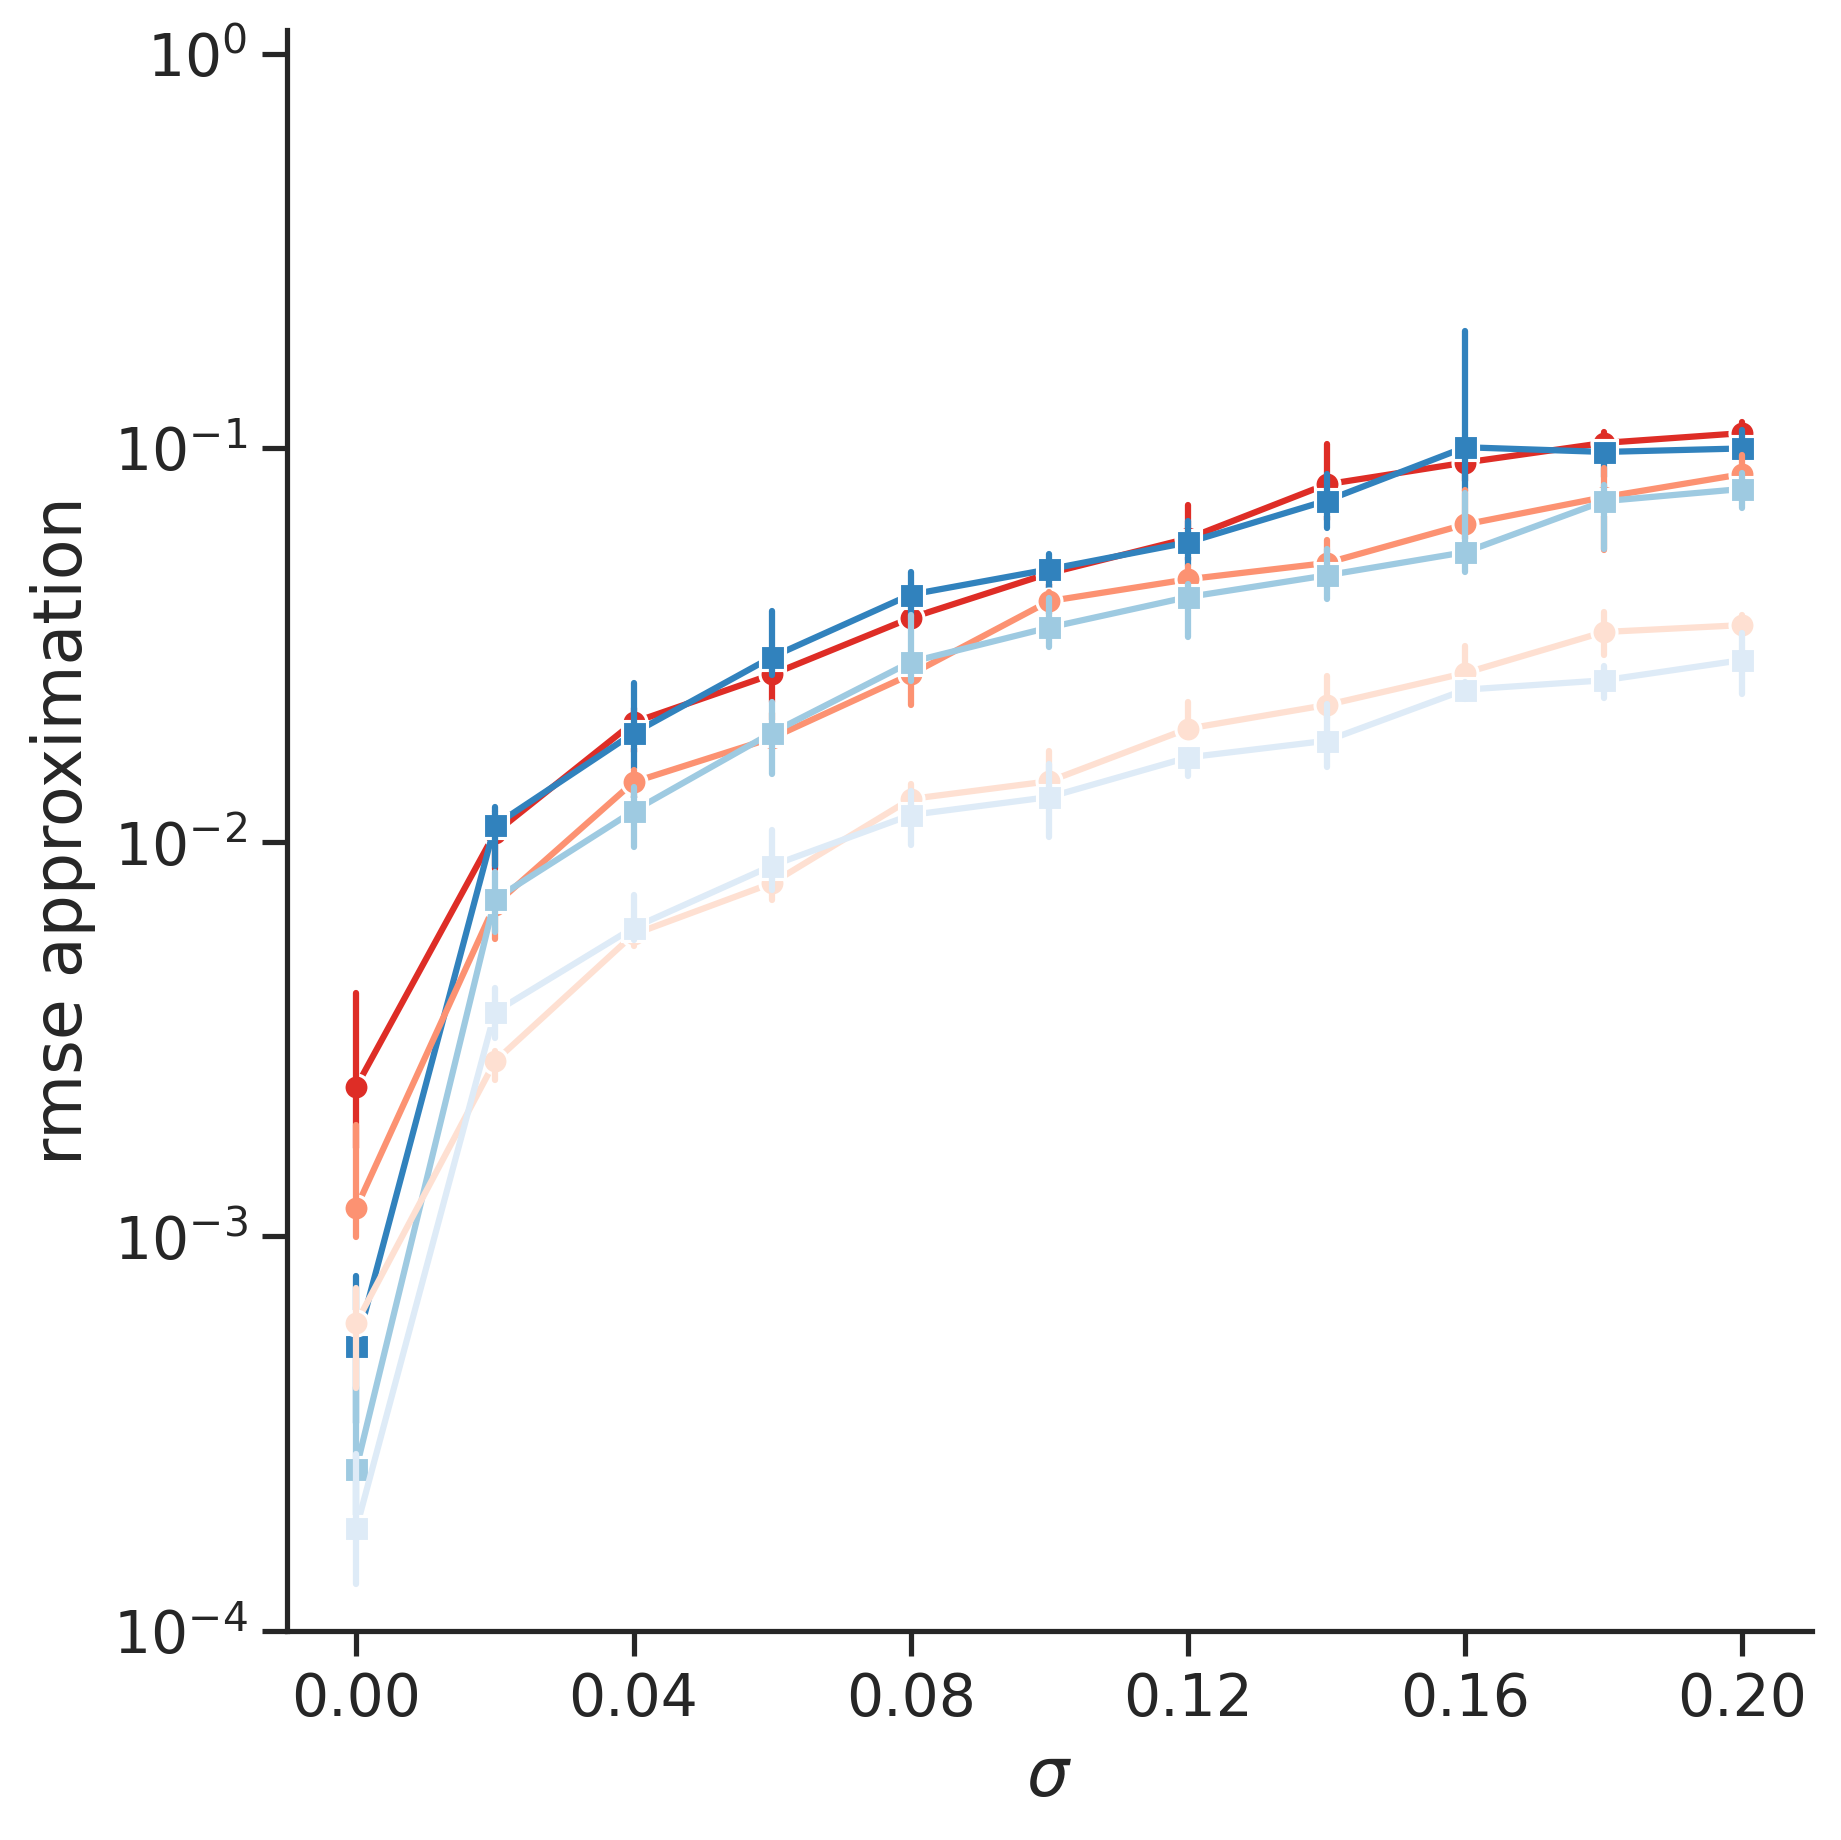

In [48]:
#Plot tanh approximations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_tanh_train[combined_tanh_train['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_train', hue='error_train', style='error_train',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse approximation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='all_approximations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
#plt.savefig(output_path+name_fig + '.png',dpi=300)
#------------------------------------------------------------------------------------------------------------------------

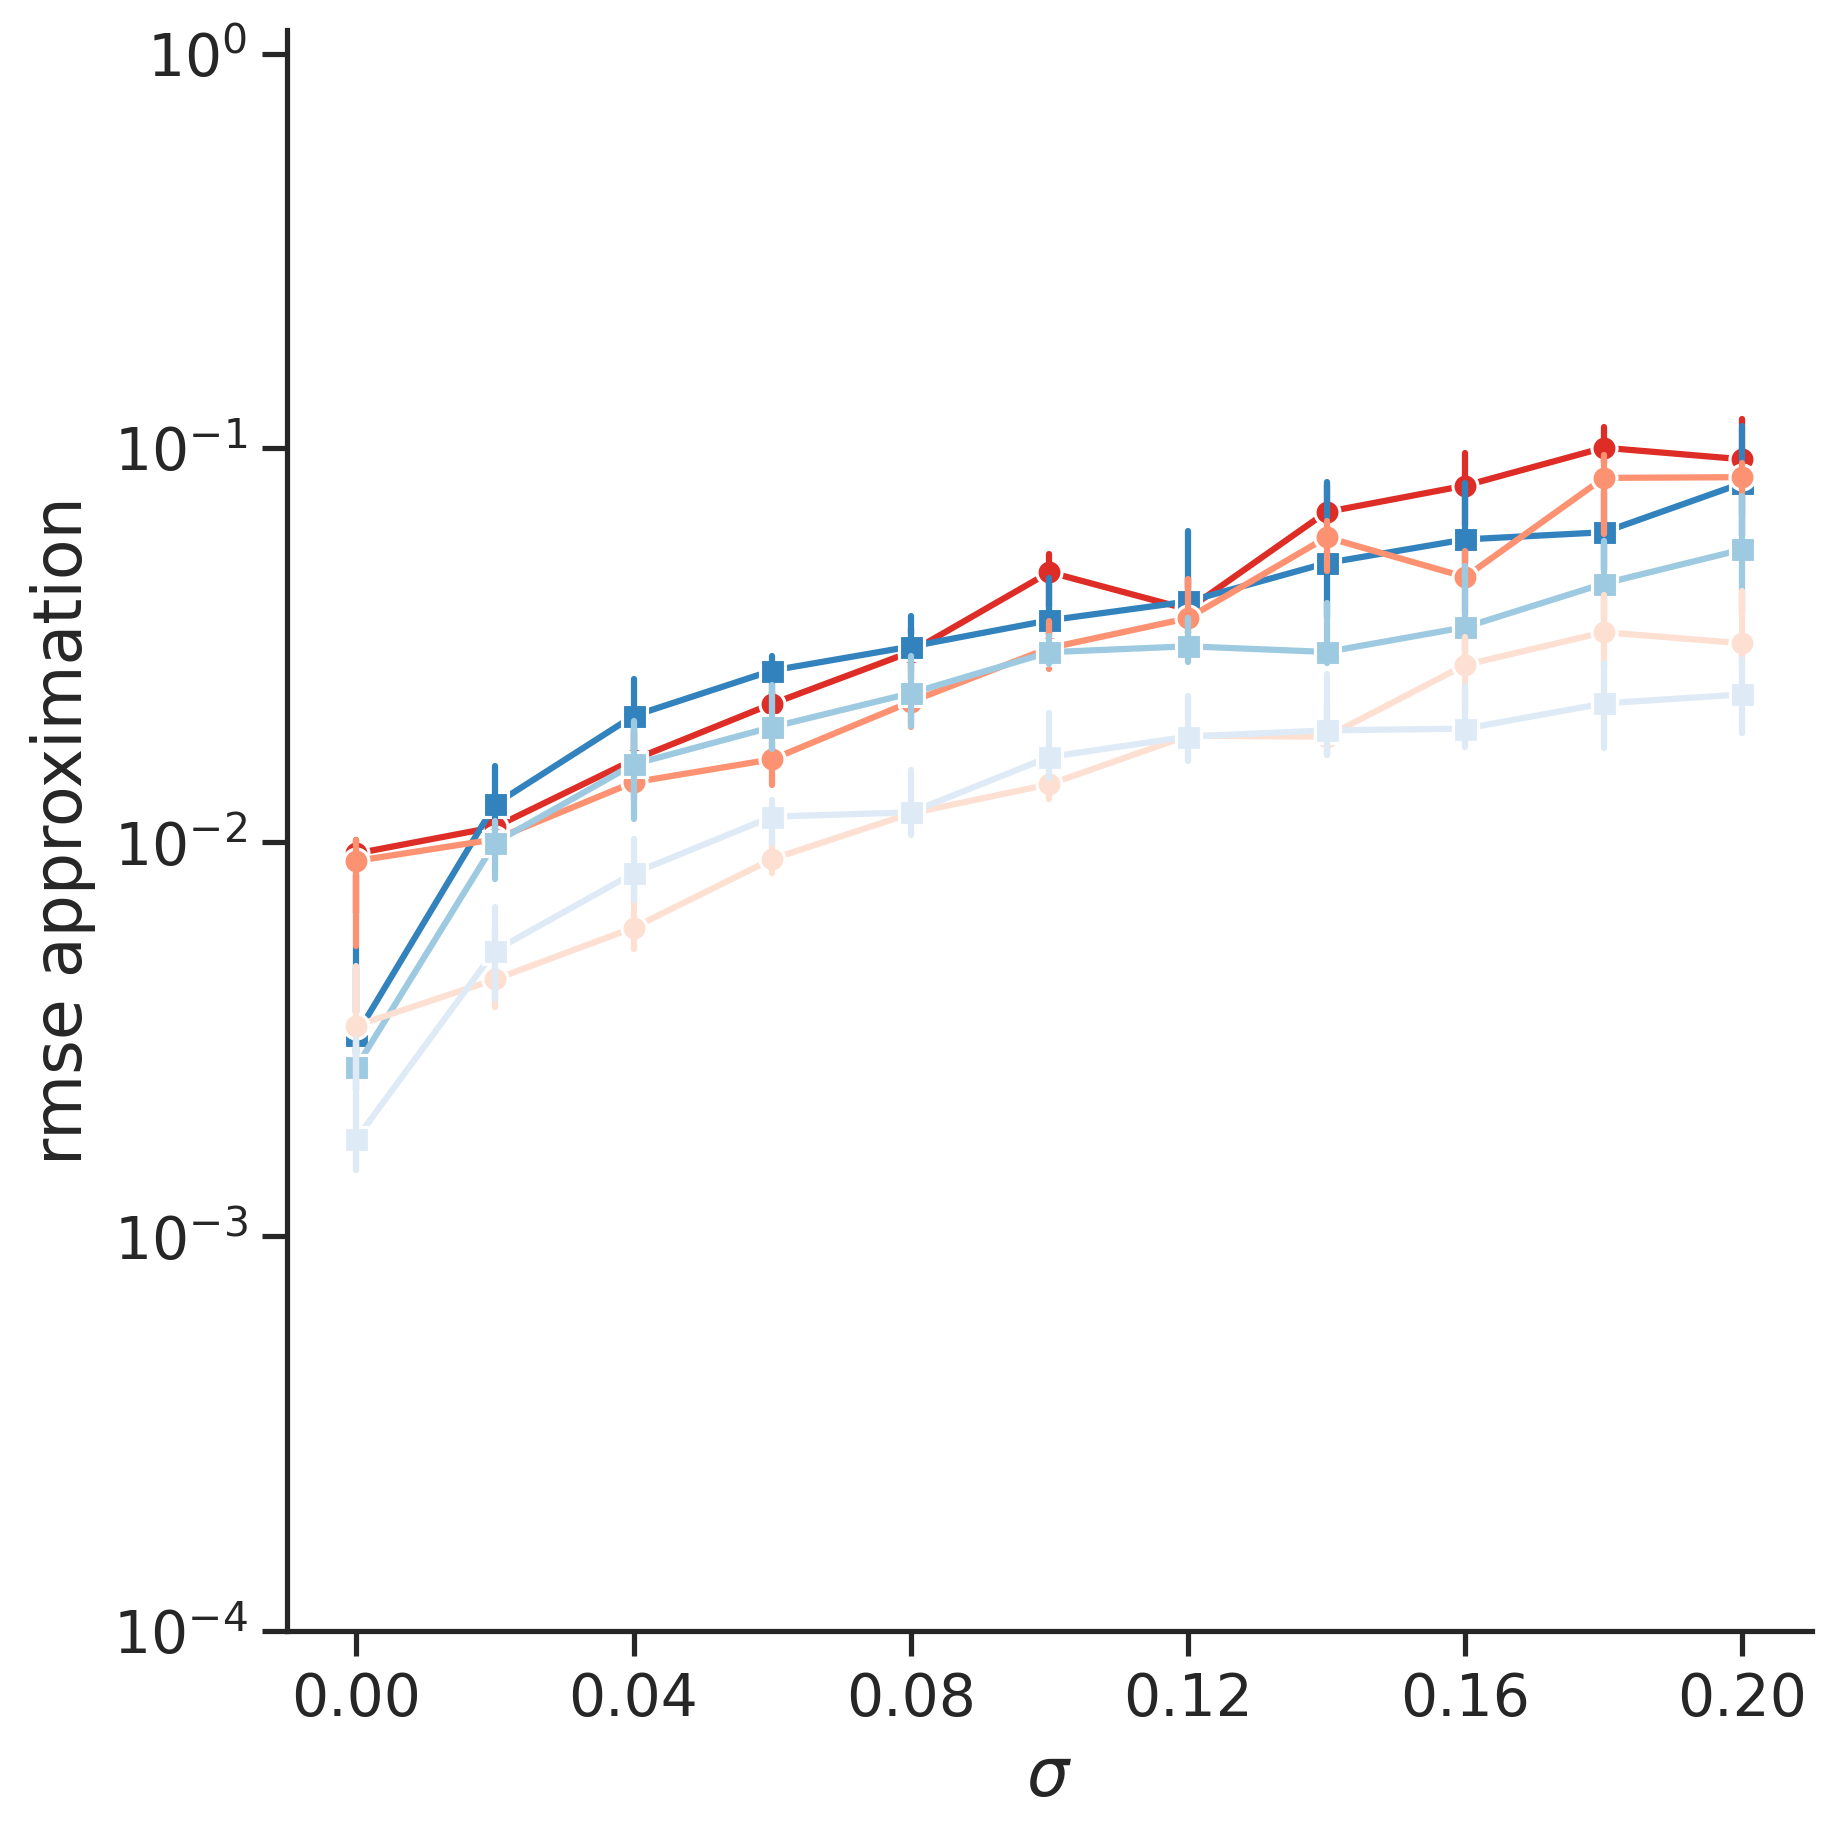

In [50]:
#Plot leaky approximations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_train[combined_leaky_train['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_train', hue='error_train', style='error_train',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse approximation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='all_approximations_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

#------------------------------------------------------------------------------------------------------------------------

,sigma,function,n,r,error_interp.,value_interp.,resolution
0,0.0,tanh,0,0,rmse_nn_interp.,0.012386,1x
1,0.0,tanh,1,0,rmse_nn_interp.,0.012122,1x
2,0.0,tanh,2,0,rmse_nn_interp.,0.006643,1x
3,0.0,tanh,3,0,rmse_nn_interp.,0.001461,1x
4,0.0,tanh,4,0,rmse_nn_interp.,0.002459,1x
...,...,...,...,...,...,...,...
985,0.2,tanh,5,2,rmse_mdl_interp.,0.037712,4e-3x
986,0.2,tanh,6,2,rmse_mdl_interp.,0.034507,4e-3x
987,0.2,tanh,7,2,rmse_mdl_interp.,0.019437,4e-3x
988,0.2,tanh,8,2,rmse_mdl_interp.,0.022793,4e-3x


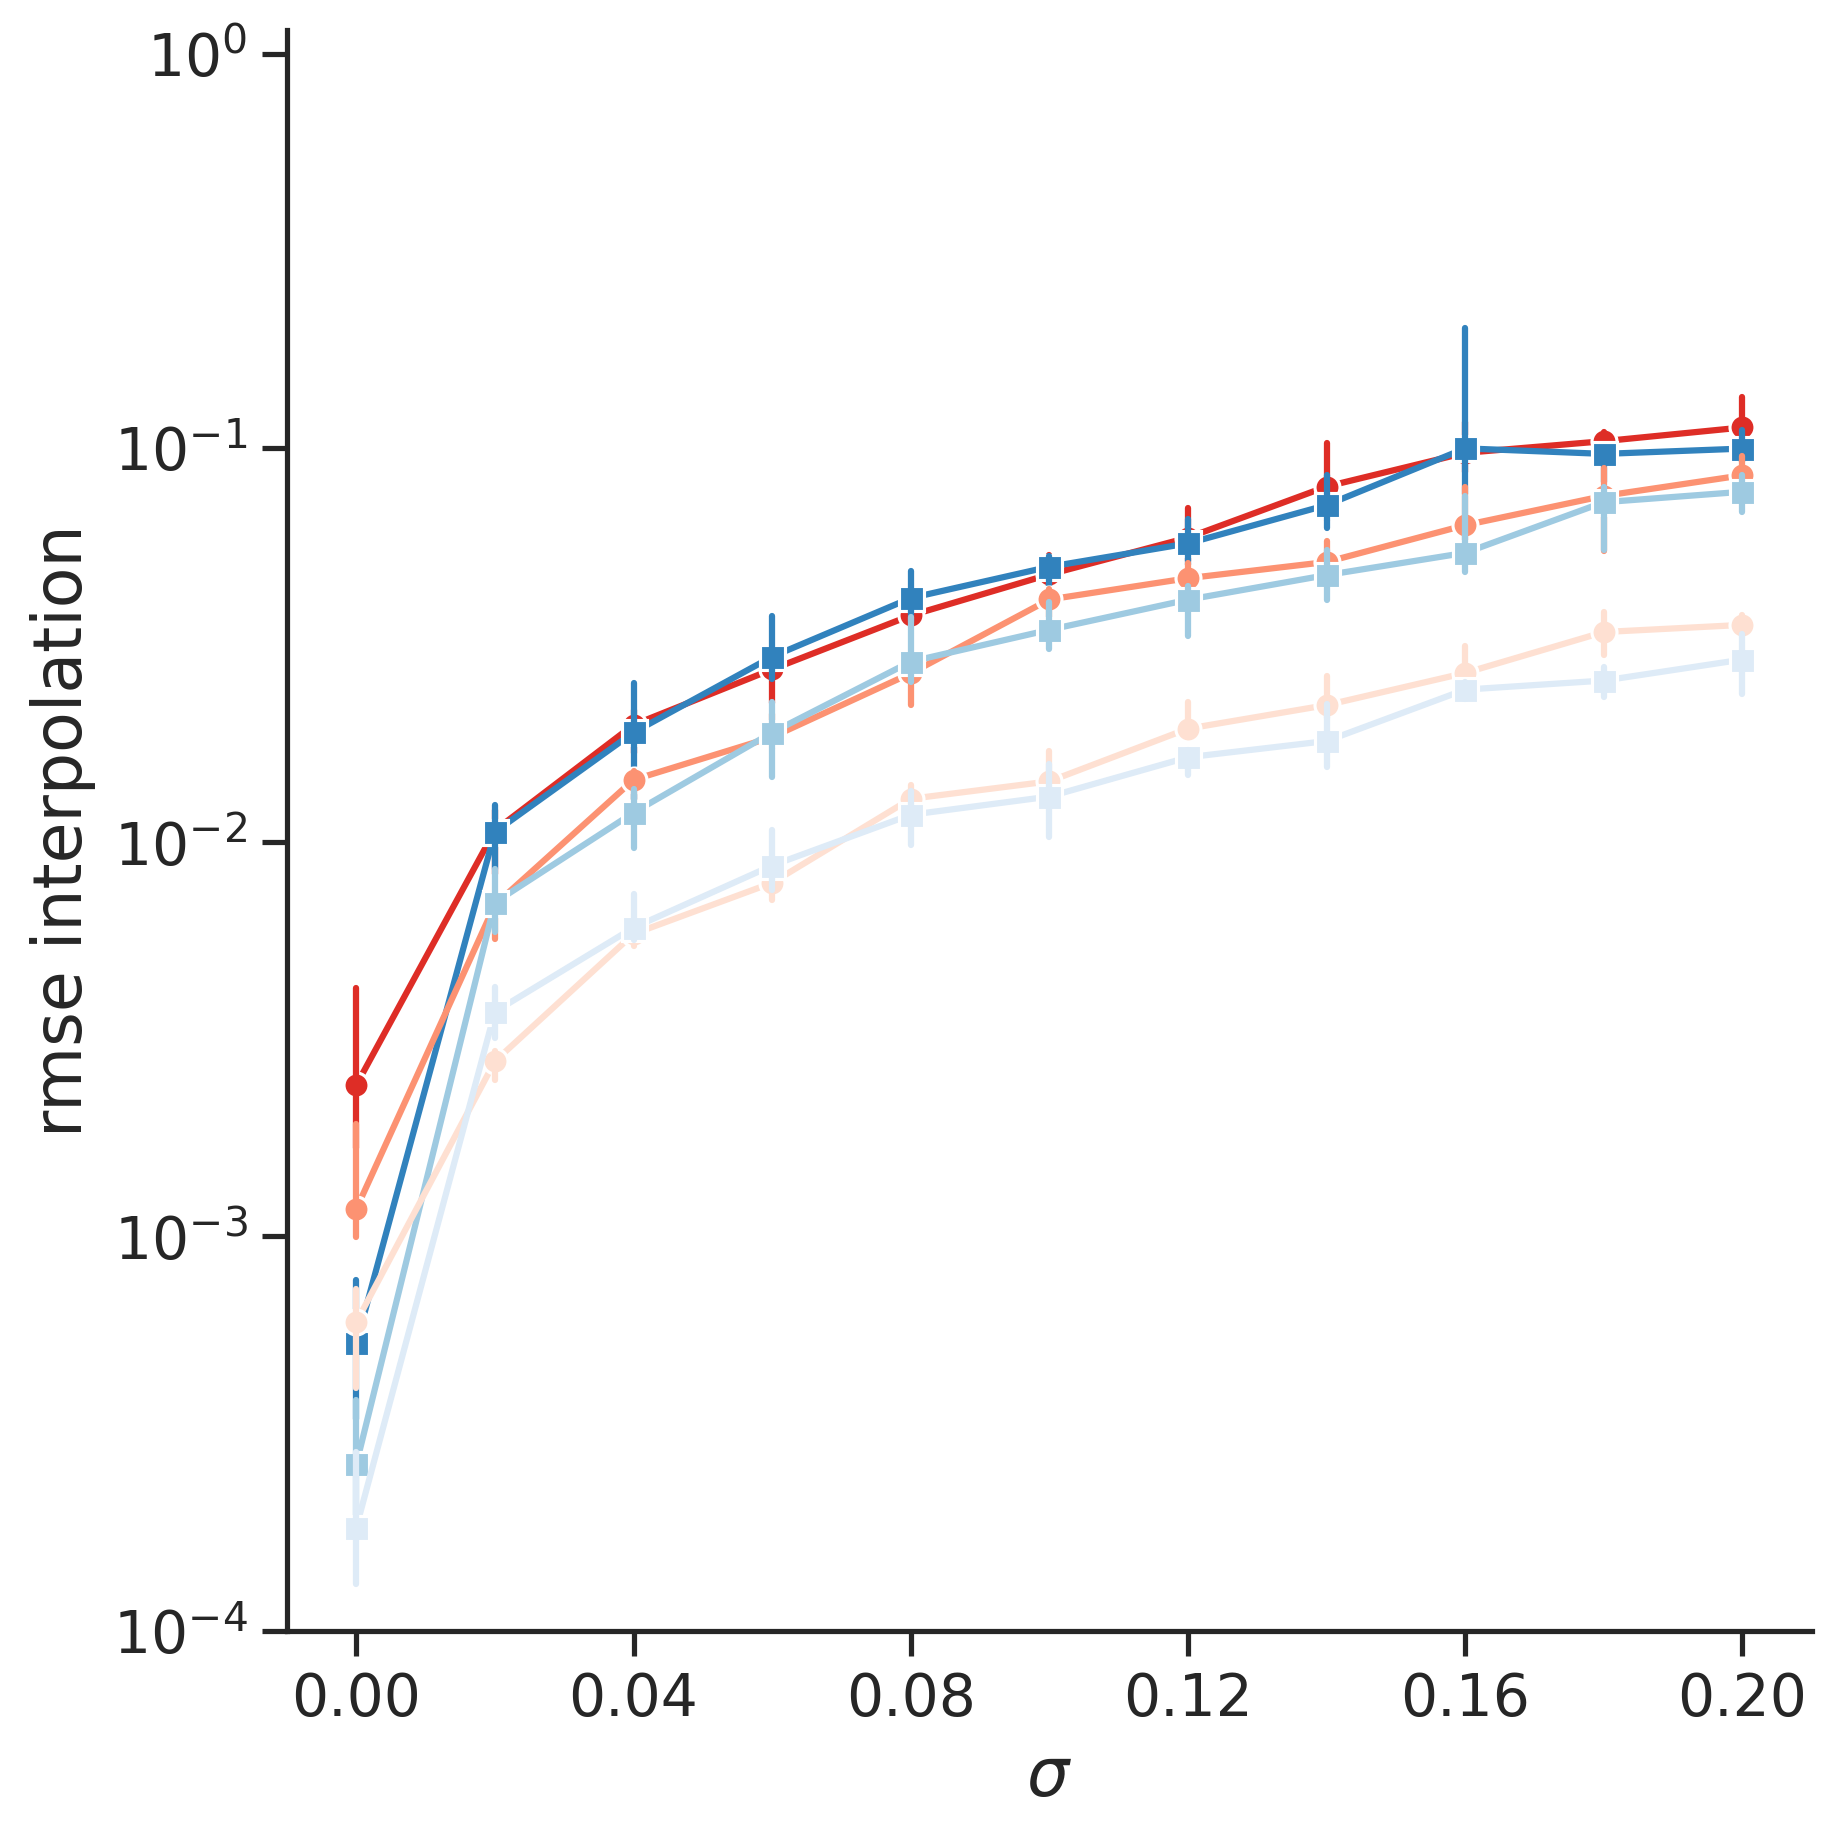

In [53]:
#Plot tanh interpolations
fig=figure(figsize=(width,height), dpi=300)

display(combined_tanh_inter)

for resolution in resolutions:
    data = combined_tanh_inter[combined_tanh_inter['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_interp.', hue='error_interp.', style='error_interp.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='all_interpolations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

#------------------------------------------------------------------------------------------------------------------------

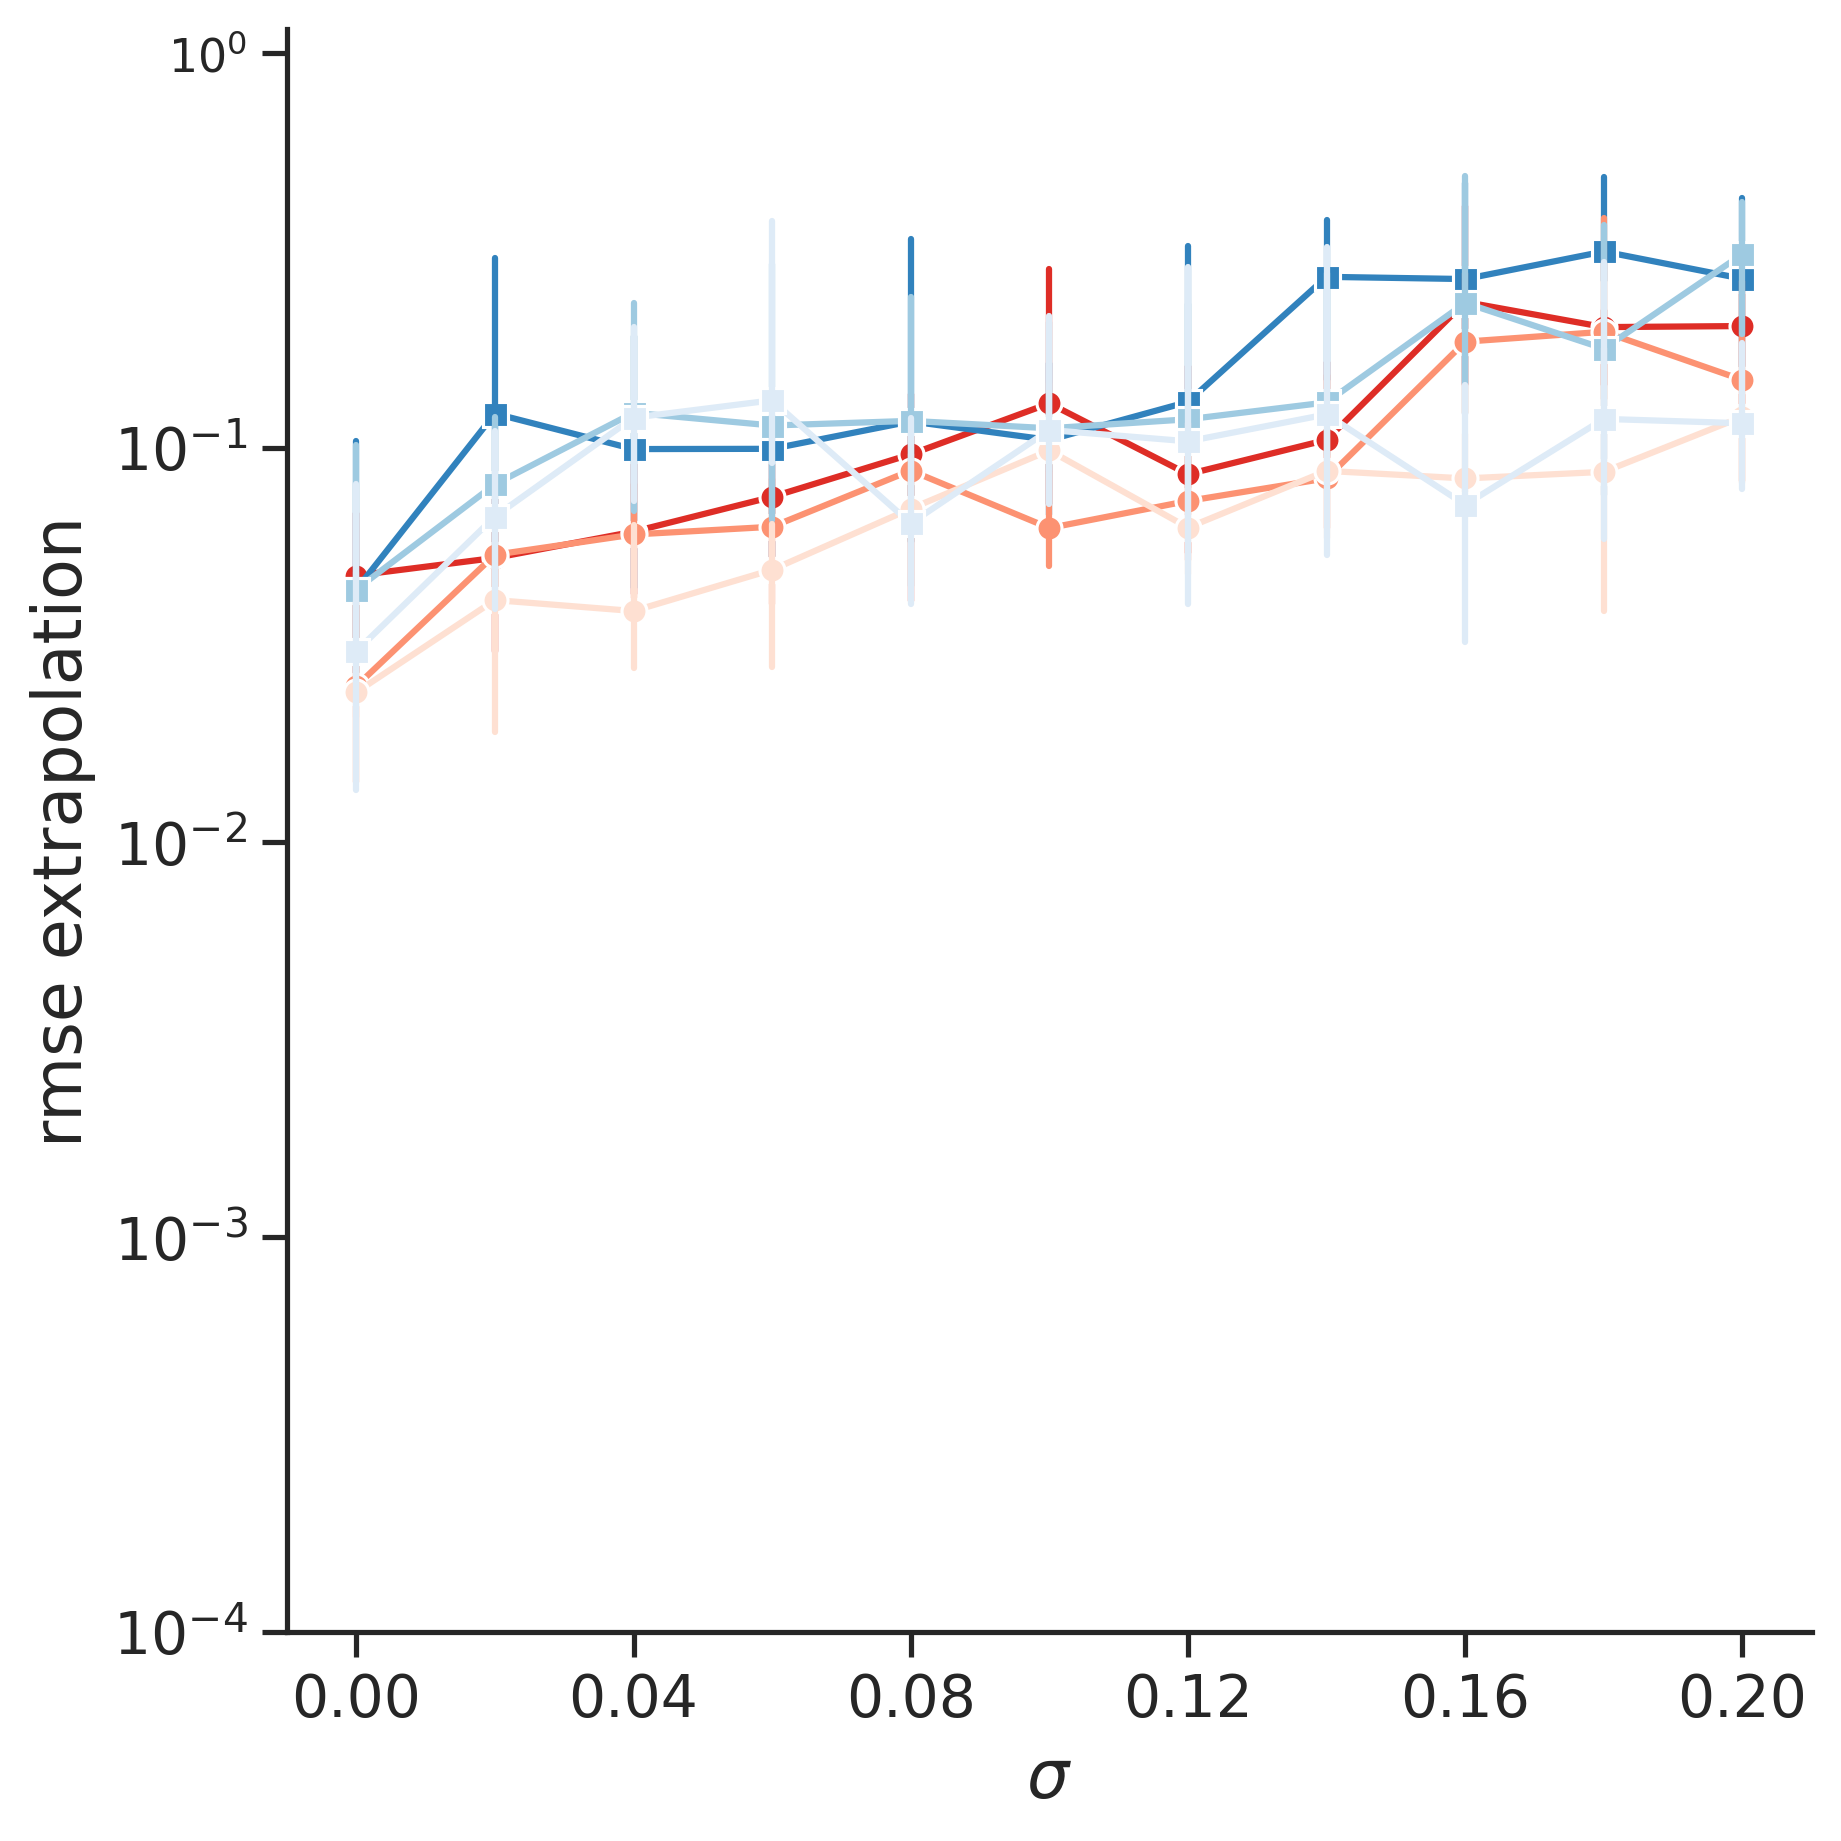

In [54]:
#Plot tanh extrapolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_tanh_extra[combined_tanh_extra['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_extrap.', hue='error_extrap.', style='error_extrap.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='all_extrapolations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

#------------------------------------------------------------------------------------------------------------------------

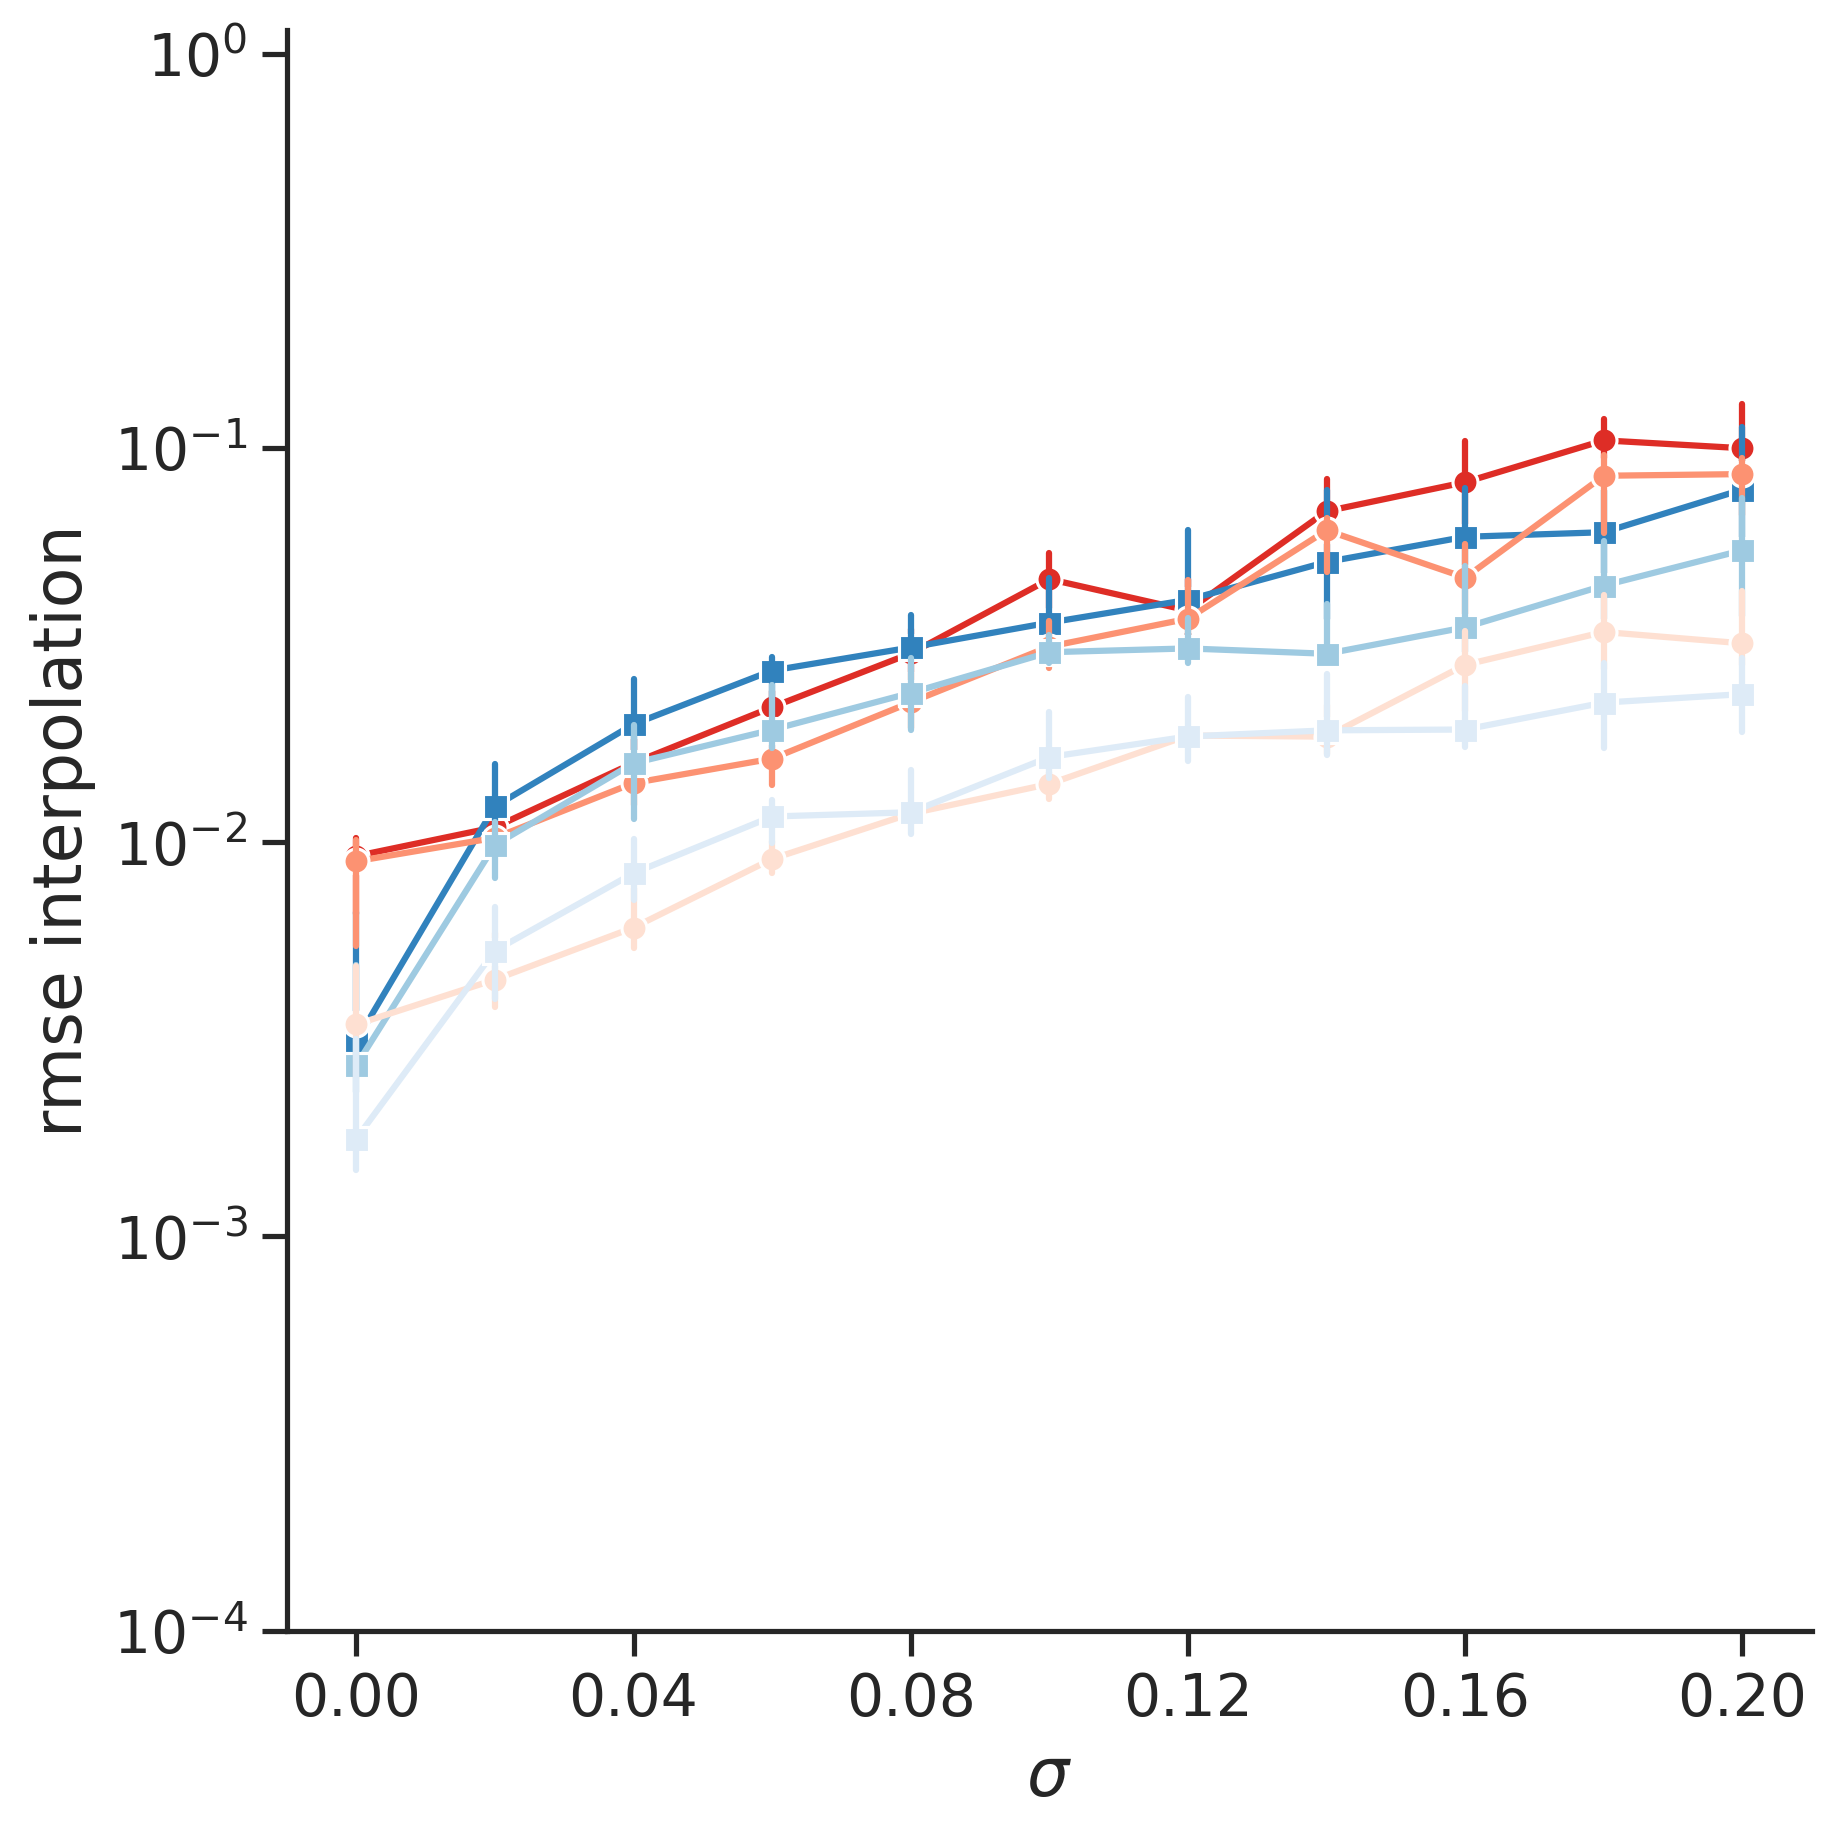

In [55]:
#Plot leaky interpolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_inter[combined_leaky_inter['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_interp.', hue='error_interp.', style='error_interp.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log");plt.minorticks_off()
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)


plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='all_interpolations_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

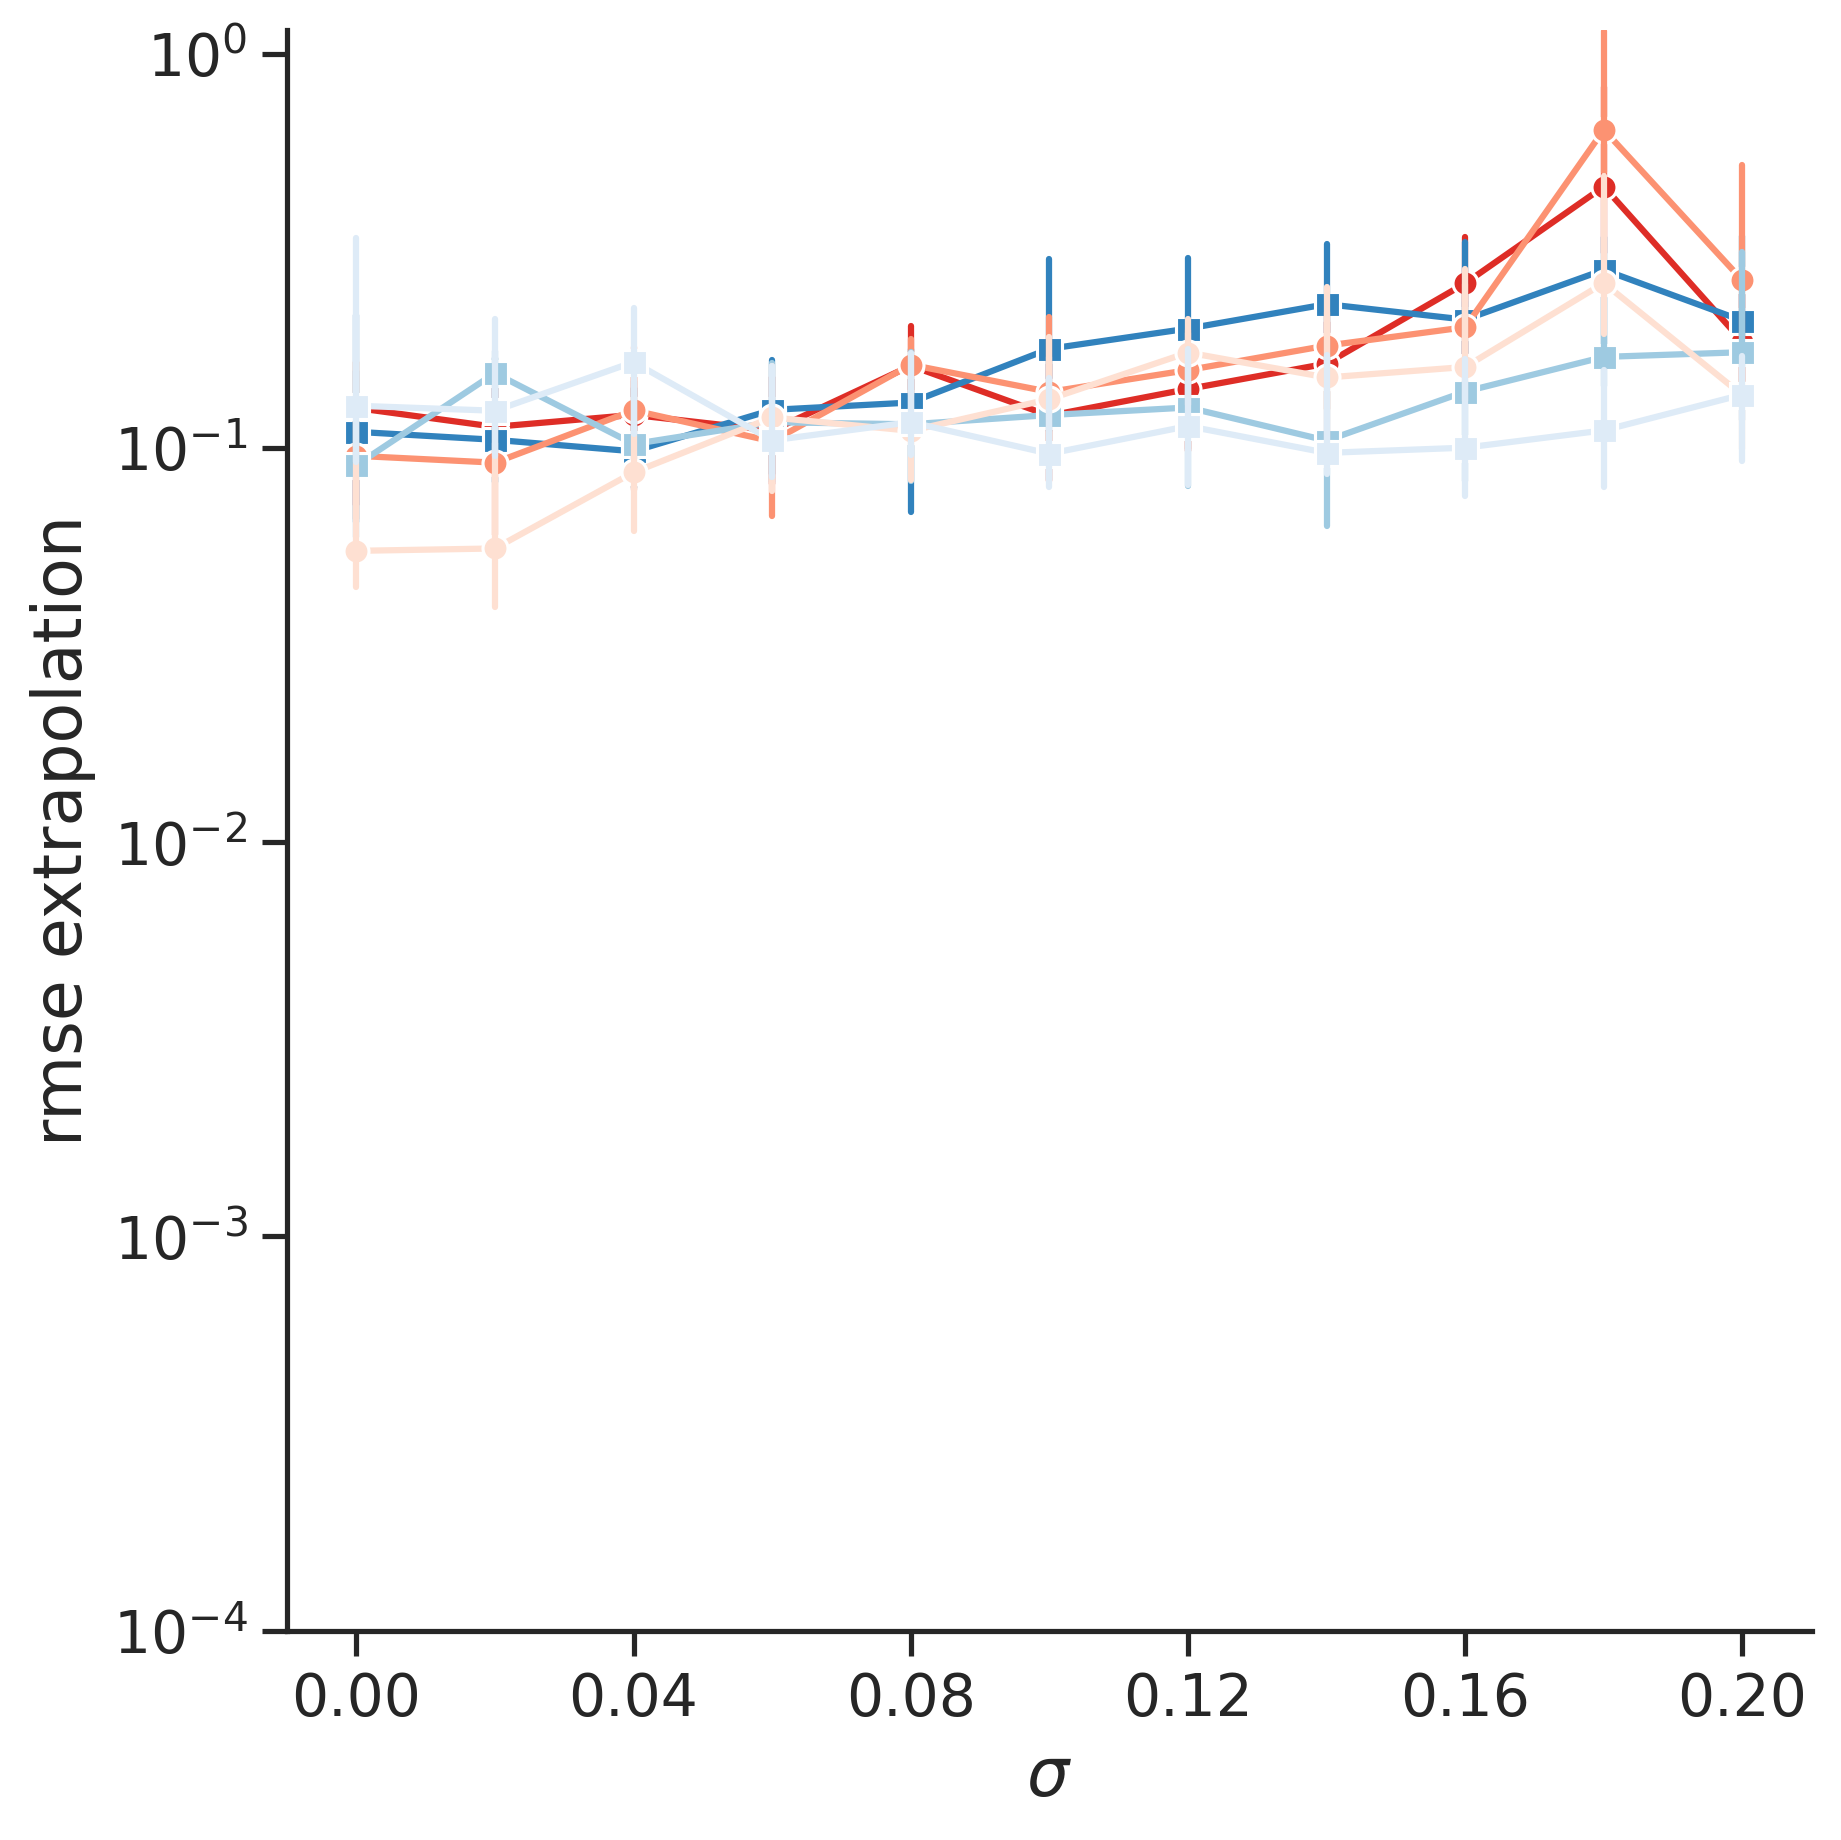

In [56]:
#Plot leaky extrapolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_extra[combined_leaky_extra['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_extrap.', hue='error_extrap.', style='error_extrap.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log");plt.minorticks_off()
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='all_extrapolations_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)
#------------------------------------------------------------------------------------------------------------------------